<a href="https://colab.research.google.com/github/proshenjitbarua06-dot/skill-morph/blob/main/Unsupervised_Clustering_of_Renewable_Energy_Markets_and_Climate_Drivers_A_UMAP_Based_Analysis_of_Clean_Energy_Dynamics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q umap-learn openpyxl
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, umap
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score


In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
# Step 1: Load Data
df = pd.read_csv('/content/drive/MyDrive/Dataset/renewable_energy_climate_nexus.csv')
print("✅ Data loaded! Shape:", df.shape)
print("Columns:", df.columns.tolist())

# Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'])

✅ Data loaded! Shape: (1253, 18)
Columns: ['Date', 'Clean_Energy_Close', 'Clean_Energy_Volume', 'Solar_Close', 'Solar_Volume', 'Wind_Close', 'Wind_Volume', 'Traditional_Energy_Close', 'Traditional_Energy_Volume', 'Texas_USA_Max_Temp_C', 'Texas_USA_Max_Wind_kmh', 'Texas_USA_Solar_Radiation_MJm2', 'Cali_USA_Max_Temp_C', 'Cali_USA_Max_Wind_kmh', 'Cali_USA_Solar_Radiation_MJm2', 'Germany_Max_Temp_C', 'Germany_Max_Wind_kmh', 'Germany_Solar_Radiation_MJm2']


In [13]:
# Preprocessing

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Using", len(numeric_cols), "numeric features")
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
X = df[numeric_cols].copy()

# Fill with Median
X = X.fillna(X.median())

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("✅ Data prepared with Median fill")

Using 17 numeric features
✅ Data prepared with Median fill


In [14]:
# Step 3: UMAP (Fast settings)
embedding = umap.UMAP(
    n_neighbors=10,
    min_dist=0.1,
    n_components=2,
    random_state=42,
    n_jobs=-1
).fit_transform(X_scaled)

print("✅ UMAP completed!")

✅ UMAP completed!


In [15]:
# Step 4: Find Best k (Fast)
scores = {}
for k in range(2, 9):
    km = KMeans(n_clusters=k, n_init=5, random_state=42).fit(embedding)
    score = silhouette_score(embedding, km.labels_)
    scores[k] = score
    print(f"k={k} → Silhouette: {score:.4f}")

best_k = max(scores, key=scores.get)
print(f"\n🎯 Best k = {best_k}")

k=2 → Silhouette: 0.5492
k=3 → Silhouette: 0.5674
k=4 → Silhouette: 0.5702
k=5 → Silhouette: 0.5875
k=6 → Silhouette: 0.5655
k=7 → Silhouette: 0.5666
k=8 → Silhouette: 0.5330

🎯 Best k = 5


In [8]:
# Step 5: Final Clustering
kmeans = KMeans(n_clusters=best_k, n_init=10, random_state=42)
hier = AgglomerativeClustering(n_clusters=best_k, linkage='ward')

labels_kmeans = kmeans.fit_predict(embedding)
labels_hier = hier.fit_predict(embedding)

# Results
def evaluate(labels):
    return {
        "Silhouette": round(silhouette_score(embedding, labels), 3),
        "Calinski-Harabasz": round(calinski_harabasz_score(embedding, labels), 1),
        "Davies-Bouldin": round(davies_bouldin_score(embedding, labels), 3)
    }

results = pd.DataFrame({
    "KMeans": evaluate(labels_kmeans),
    "Hierarchical": evaluate(labels_hier)
}).T

print("\n📊 Clustering Quality:")
print(results)


📊 Clustering Quality:
              Silhouette  Calinski-Harabasz  Davies-Bouldin
KMeans             0.587        4061.800049           0.548
Hierarchical       0.586        4040.800049           0.548


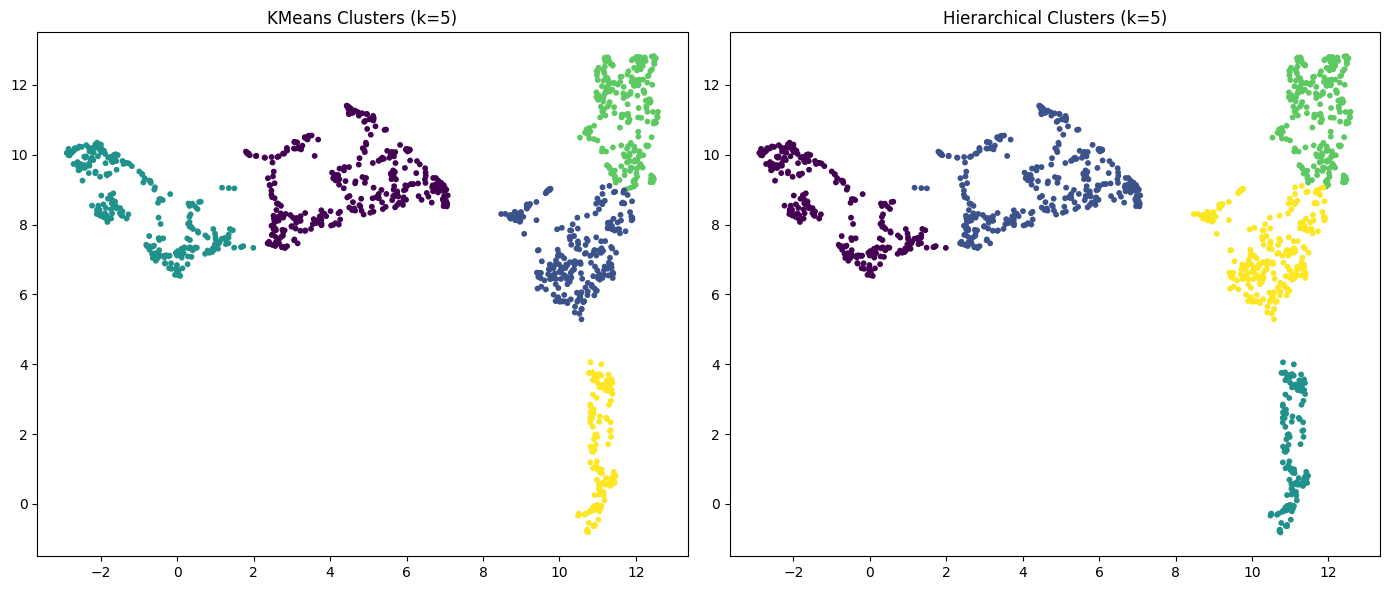

In [9]:
# Step 6: Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].scatter(embedding[:, 0], embedding[:, 1], c=labels_kmeans, cmap='viridis', s=10)
axes[0].set_title(f"KMeans Clusters (k={best_k})")
axes[1].scatter(embedding[:, 0], embedding[:, 1], c=labels_hier, cmap='viridis', s=10)
axes[1].set_title(f"Hierarchical Clusters (k={best_k})")
plt.tight_layout()
plt.show()

In [16]:
# Add cluster label to original data
df['Cluster'] = labels_kmeans

# Group by cluster and see average values
cluster_summary = df.groupby('Cluster').mean(numeric_only=True).round(2)

# Show key columns
key_columns = ['Clean_Energy_Close', 'Solar_Close', 'Wind_Close',
               'Traditional_Energy_Close', 'Texas_USA_Max_Temp_C',
               'Cali_USA_Solar_Radiation_MJm2', 'Germany_Max_Temp_C']

print("📋 Cluster Profiles (Average Values):")
print(cluster_summary[key_columns])

📋 Cluster Profiles (Average Values):
         Clean_Energy_Close  Solar_Close  Wind_Close  \
Cluster                                                
0                     18.76        74.09       16.72   
1                     13.47        41.09       16.46   
2                     20.74        80.44       19.37   
3                     12.65        40.33       14.91   
4                     16.47        48.62       20.34   

         Traditional_Energy_Close  Texas_USA_Max_Temp_C  \
Cluster                                                   
0                           36.78                 28.13   
1                           42.26                 32.97   
2                           24.22                 24.99   
3                           41.84                 19.87   
4                           46.27                 24.49   

         Cali_USA_Solar_Radiation_MJm2  Germany_Max_Temp_C  
Cluster                                                     
0                                2

In [17]:
import seaborn as sns

# Add Date components
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['YearMonth'] = df['Date'].dt.to_period('M')

# Cluster distribution by Year
print("=== Cluster Distribution by Year ===")
year_dist = pd.crosstab(df['Year'], df['Cluster'], normalize='index').round(3) * 100
print(year_dist)

# Cluster distribution by Month
print("\n=== Cluster Distribution by Month ===")
month_dist = pd.crosstab(df['Month'], df['Cluster'], normalize='index').round(3) * 100
print(month_dist)

=== Cluster Distribution by Year ===
Cluster     0     1      2     3      4
Year                                   
2021      0.0   0.0  100.0   0.0    0.0
2022     76.1   0.0   23.9   0.0    0.0
2023     58.0  16.0    1.6  24.4    0.0
2024      0.0  41.7    0.0  50.0    8.3
2025      0.0  43.6    0.0  23.2   33.2
2026      0.0   0.0    0.0   0.0  100.0

=== Cluster Distribution by Month ===
Cluster     0     1     2     3     4
Month                                
1        18.8   0.0  20.8  40.6  19.8
2        18.8   0.0  20.8  40.6  19.8
3        28.0   5.6  27.1  32.7   6.5
4        32.0  29.1  26.2  12.6   0.0
5        40.6  40.6  18.9   0.0   0.0
6        40.8  37.9  21.4   0.0   0.0
7        38.1  41.9  20.0   0.0   0.0
8        25.2  53.2  19.8   0.0   1.8
9        20.4  30.1  20.4   1.0  28.2
10       19.1   1.8  19.1  30.9  29.1
11       20.6   0.0  20.6  40.2  18.6
12       18.9   0.0  21.7  38.7  20.8


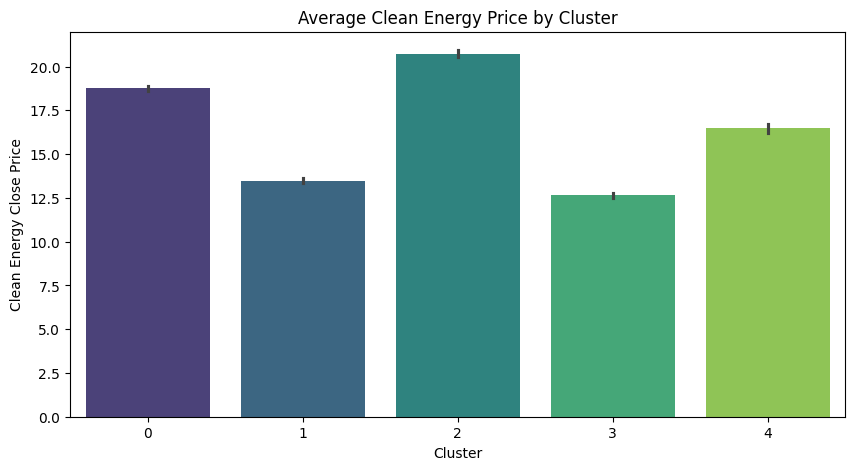

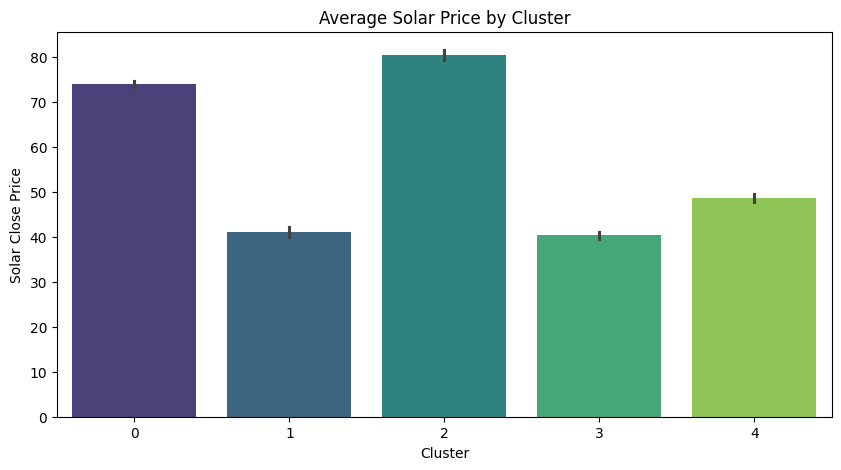

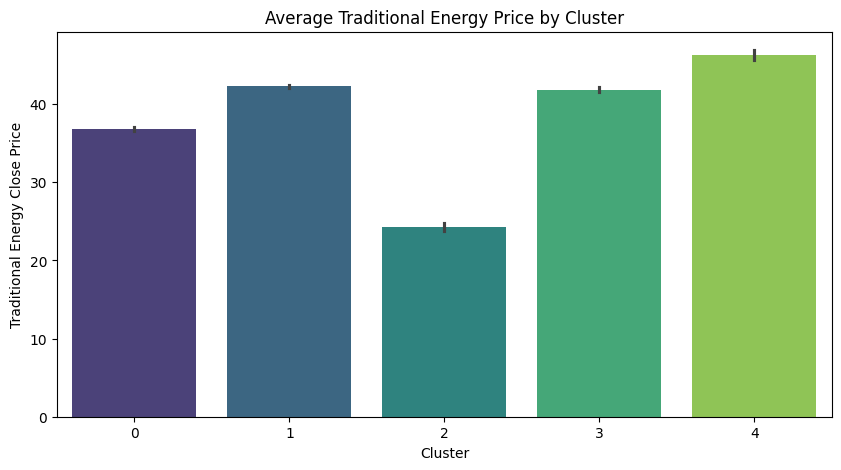

In [18]:
# Average Clean Energy Price per Cluster
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='Cluster', y='Clean_Energy_Close', palette='viridis')
plt.title('Average Clean Energy Price by Cluster')
plt.ylabel('Clean Energy Close Price')
plt.show()

# Average Solar Price per Cluster
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='Cluster', y='Solar_Close', palette='viridis')
plt.title('Average Solar Price by Cluster')
plt.ylabel('Solar Close Price')
plt.show()

# Average Traditional Energy Price per Cluster
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='Cluster', y='Traditional_Energy_Close', palette='viridis')
plt.title('Average Traditional Energy Price by Cluster')
plt.ylabel('Traditional Energy Close Price')
plt.show()

<Figure size 1200x600 with 0 Axes>

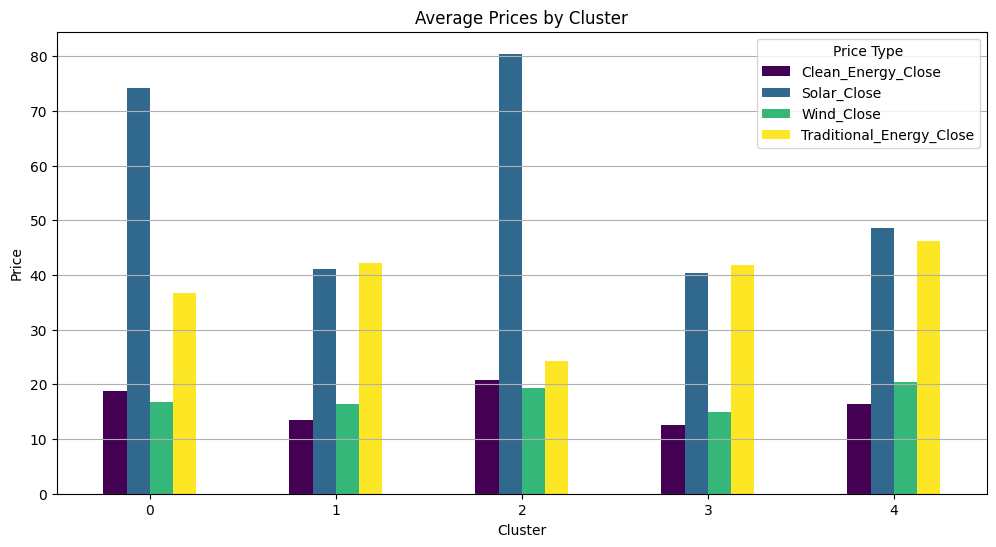

In [19]:
# Multi-price comparison
price_cols = ['Clean_Energy_Close', 'Solar_Close', 'Wind_Close', 'Traditional_Energy_Close']

cluster_means = df.groupby('Cluster')[price_cols].mean().round(2)

plt.figure(figsize=(12, 6))
cluster_means.plot(kind='bar', figsize=(12, 6), colormap='viridis')
plt.title('Average Prices by Cluster')
plt.ylabel('Price')
plt.xticks(rotation=0)
plt.legend(title='Price Type')
plt.grid(axis='y')
plt.show()